<a href="https://colab.research.google.com/github/Rudi1410/BigData_Spotify/blob/main/ETL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyarrow fastparquet -q
!pip install pyspark -q

# **Load Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Spotify Analysis") \
    .getOrCreate()

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/spotify/chart_song_daily.parquet"

df = spark.read.parquet(file_path)

In [ ]:
df.show(5)

+----------+-------+----+--------------------+--------------------+--------------------+--------------------+---------+-------------+-------------+-------+----------------+------------+----------+----------+----------+------------+--------------------+----------------------+--------------------+--------------------+----------------------+----+-----+---+
|      date|country|rank|                 uri|        artist_names|          track_name|               label|peak_rank|previous_rank|days_on_chart|streams|consecutive_days|entry_status| peak_date|entry_rank|entry_date|release_date|         artist_uris|estimated_artist_names|estimated_track_name|     estimated_label|estimated_release_date|year|month|day|
+----------+-------+----+--------------------+--------------------+--------------------+--------------------+---------+-------------+-------------+-------+----------------+------------+----------+----------+----------+------------+--------------------+----------------------+-------------

In [ ]:
df = df.drop("year", "month", "day")

In [ ]:
df.show(5)

+----------+-------+----+--------------------+--------------------+--------------------+--------------------+---------+-------------+-------------+-------+----------------+------------+----------+----------+----------+------------+--------------------+----------------------+--------------------+--------------------+----------------------+
|      date|country|rank|                 uri|        artist_names|          track_name|               label|peak_rank|previous_rank|days_on_chart|streams|consecutive_days|entry_status| peak_date|entry_rank|entry_date|release_date|         artist_uris|estimated_artist_names|estimated_track_name|     estimated_label|estimated_release_date|
+----------+-------+----+--------------------+--------------------+--------------------+--------------------+---------+-------------+-------------+-------+----------------+------------+----------+----------+----------+------------+--------------------+----------------------+--------------------+--------------------+-

In [ ]:
from pyspark.sql import functions as F

total_rows = df.count()
unique_uri = df.select("uri").distinct().count()

print(f"Total baris: {total_rows:,}")
print(f"Unique uri: {unique_uri:,}")
print(f"Rata-rata baris per uri: {total_rows/unique_uri:.2f}")

# Cek kombinasi mana yang membuat uri "terlihat" duplikat -- biasanya uri+country+date sudah unik
dup_check = df.groupBy("uri", "country", "date").count().filter(F.col("count") > 1)
print("Baris yang masih duplikat meski sudah uri+country+date:", dup_check.count())

Total baris: 42,504,067
Unique uri: 240,531
Rata-rata baris per uri: 176.71
Baris yang masih duplikat meski sudah uri+country+date: 192


In [ ]:
from pyspark.sql import functions as F

# monotonically_increasing_id() -> unik dan deterministik selama partisi tidak diubah,
# cocok untuk surrogate key per baris di seluruh dataframe
df = df.withColumn("row_id", F.monotonically_increasing_id())

df.select("row_id", "uri", "country", "date").show(10)

+------+--------------------+-------+----------+
|row_id|                 uri|country|      date|
+------+--------------------+-------+----------+
|     0|spotify:track:6u7...|     ae|2019-06-04|
|     1|spotify:track:3HV...|     ae|2019-06-04|
|     2|spotify:track:2Fx...|     ae|2019-06-04|
|     3|spotify:track:3Kk...|     ae|2019-06-04|
|     4|spotify:track:53C...|     ae|2019-06-04|
|     5|spotify:track:6Ls...|     ae|2019-06-04|
|     6|spotify:track:7Dc...|     ae|2019-06-04|
|     7|spotify:track:4y3...|     ae|2019-06-04|
|     8|spotify:track:6Tq...|     ae|2019-06-04|
|     9|spotify:track:2dp...|     ae|2019-06-04|
+------+--------------------+-------+----------+
only showing top 10 rows


In [ ]:
estimated_pairs = {
    "artist_names": "estimated_artist_names",
    "track_name": "estimated_track_name",
    "label": "estimated_label",
    "release_date": "estimated_release_date"
}
estimated_cols = list(estimated_pairs.values())
all_cols = df.columns

non_estimated_cols = [c for c in all_cols if c not in estimated_cols]

df_main = df.select(*non_estimated_cols)  # row_id otomatis ikut karena sudah ada di df
df_estimated = df.select("row_id", *estimated_cols)  # key sekarang row_id, bukan uri

print("Jumlah baris df_main:", df_main.count())
print("Jumlah baris df_estimated:", df_estimated.count())

Jumlah baris df_main: 42504067
Jumlah baris df_estimated: 42504067


# **Data Cleaning**

Mengecek Data Null

In [ ]:
# ============================================
# 1. CEK NULL per kolom
# ============================================
from pyspark.sql import functions as F

print("=" * 50)
print("NULL VALUES PER KOLOM")
print("=" * 50)

total = df_main.count()

null_counts = df_main.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in df_main.columns
]).toPandas().T

null_counts.columns        = ["null_count"]
null_counts["persentase"]  = (null_counts["null_count"] / total * 100).round(2)
null_counts["status"]      = null_counts["null_count"].apply(lambda x: "✅ OK" if x == 0 else "⚠️ ADA NULL")

print(null_counts.to_string())

NULL VALUES PER KOLOM
                  null_count  persentase       status
date                       0        0.00         ✅ OK
country                    0        0.00         ✅ OK
rank                       0        0.00         ✅ OK
uri                        0        0.00         ✅ OK
artist_names           44711        0.11  ⚠️ ADA NULL
track_name             44711        0.11  ⚠️ ADA NULL
label                  42993        0.10  ⚠️ ADA NULL
peak_rank                  0        0.00         ✅ OK
previous_rank              0        0.00         ✅ OK
days_on_chart              0        0.00         ✅ OK
streams                    0        0.00         ✅ OK
consecutive_days           0        0.00         ✅ OK
entry_status               0        0.00         ✅ OK
peak_date                  0        0.00         ✅ OK
entry_rank                 0        0.00         ✅ OK
entry_date                 0        0.00         ✅ OK
release_date          631597        1.49  ⚠️ ADA NULL
artist

Mengecek Data Duplikat

In [ ]:
# ============================================
# 2. CEK DUPLIKAT
# ============================================
print("=" * 50)
print("CEK DATA DUPLIKAT")
print("=" * 50)

total      = df_main.count()
distinct   = df_main.distinct().count()
duplicates = total - distinct

print(f"Total baris       : {total:,}")
print(f"Baris unik        : {distinct:,}")
print(f"Baris duplikat    : {duplicates:,}")
print(f"Persentase duplikat: {duplicates/total*100:.2f}%")

if duplicates > 0:
    print("\n⚠️  Ada duplikat! Contoh baris duplikat:")
    df_main.groupBy(df_main.columns) \
        .count() \
        .filter(F.col("count") > 1) \
        .orderBy(F.col("count").desc()) \
        .show(5)
else:
    print("\n✅ Tidak ada duplikat!")

CEK DATA DUPLIKAT
Total baris       : 42,504,067
Baris unik        : 42,504,067
Baris duplikat    : 0
Persentase duplikat: 0.00%

✅ Tidak ada duplikat!


Melihat distribusi kolom numerik

In [ ]:
# ============================================
# 3. DESCRIBE — statistik deskriptif
# ============================================
print("=" * 50)
print("STATISTIK DESKRIPTIF")
print("=" * 50)

# Kolom numerik saja
exclude_cols  = ["track_uri", "country"]
numeric_cols  = [c for c in df_main.columns
                 if c not in exclude_cols
                 and dict(df_main.dtypes)[c] in ["int", "bigint", "double", "float", "long"]]

# describe() → count, mean, stddev, min, max
df_main.select(numeric_cols).describe().show(truncate=False)

STATISTIK DESKRIPTIF
+-------+-----------------+-----------------+-----------------+-----------------+------------------+------------------+------------------+---------------------+
|summary|rank             |peak_rank        |previous_rank    |days_on_chart    |streams           |consecutive_days  |entry_rank        |row_id               |
+-------+-----------------+-----------------+-----------------+-----------------+------------------+------------------+------------------+---------------------+
|count  |42504067         |42504067         |42504067         |42504067         |42504067          |42504067          |42504067          |42504067             |
|mean   |98.1721579960807 |34.47292815532217|87.21204544967426|265.2216344379468|67698.12213918258 |129.07162474593315|102.47138004464372|3.301443839545927E10 |
|stddev |57.72833090132881|39.43485430163373|58.5926276582425 |357.1383878406645|243746.60402645738|206.36286209237335|70.05415221149957 |2.1435000240738777E10|
|min    |1   

In [ ]:
# ============================================
# 4. SUMMARY LENGKAP — tambah percentile (Q1, median, Q3)
# ============================================
print("=" * 50)
print("SUMMARY LENGKAP (dengan Percentile)")
print("=" * 50)

df_main.select(numeric_cols) \
    .summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max") \
    .show(truncate=False)

SUMMARY LENGKAP (dengan Percentile)
+-------+-----------------+-----------------+-----------------+-----------------+------------------+------------------+------------------+---------------------+
|summary|rank             |peak_rank        |previous_rank    |days_on_chart    |streams           |consecutive_days  |entry_rank        |row_id               |
+-------+-----------------+-----------------+-----------------+-----------------+------------------+------------------+------------------+---------------------+
|count  |42504067         |42504067         |42504067         |42504067         |42504067          |42504067          |42504067          |42504067             |
|mean   |98.1721579960807 |34.47292815532217|87.21204544967426|265.2216344379468|67698.12213918258 |129.07162474593315|102.47138004464372|3.301443839545927E10 |
|stddev |57.72833090132881|39.43485430163373|58.5926276582425 |357.1383878406645|243746.60402645738|206.36286209237335|70.05415221149957 |2.1435000240738777E10

Outlier

In [ ]:
from pyspark.sql import functions as F

validity_checks = df_main.agg(
    F.sum(F.when(F.col("streams") < 1, 1).otherwise(0)).alias("invalid_negative_streams"),
    F.sum(F.when((F.col("rank") < 1) | (F.col("rank") > 200), 1).otherwise(0)).alias("invalid_rank_range"),
    F.sum(F.when(F.col("days_on_chart") < 1, 1).otherwise(0)).alias("invalid_negative_days"),
    F.sum(F.when(F.col("consecutive_days") < 1, 1).otherwise(0)).alias("invalid_negative_consecutive"),
    F.sum(F.when(F.col("previous_rank") < -1, 1).otherwise(0)).alias("invalid_negative_previous_rank"),
    F.sum(F.when(F.col("entry_rank") < 1, 1).otherwise(0)).alias("invalid_negative_entry_rank"),
    F.sum(F.when(F.col("peak_rank") < 1, 1).otherwise(0)).alias("invalid_peak_rank"),
)
validity_checks.show()

+------------------------+------------------+---------------------+----------------------------+------------------------------+---------------------------+-----------------+
|invalid_negative_streams|invalid_rank_range|invalid_negative_days|invalid_negative_consecutive|invalid_negative_previous_rank|invalid_negative_entry_rank|invalid_peak_rank|
+------------------------+------------------+---------------------+----------------------------+------------------------------+---------------------------+-----------------+
|                       0|                 0|                    0|                           0|                             0|                          0|                0|
+------------------------+------------------+---------------------+----------------------------+------------------------------+---------------------------+-----------------+



In [ ]:
from pyspark.sql import functions as F
import pandas as pd

numeric_cols = ["rank", "peak_rank", "previous_rank", "days_on_chart", "streams", "consecutive_days", "entry_rank"]

total_rows = df_main.count()
outlier_summary = []

for col_name in numeric_cols:
    q1, q3 = df.approxQuantile(col_name, [0.25, 0.75], 0.01)  # relativeError=0.01 cukup akurat, jauh lebih cepat dari exact
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    n_outliers = df_main.filter((F.col(col_name) < lower_bound) | (F.col(col_name) > upper_bound)).count()

    outlier_summary.append({
        "column": col_name, "Q1": q1, "Q3": q3, "IQR": iqr,
        "lower_bound": lower_bound, "upper_bound": upper_bound,
        "n_outliers": n_outliers, "pct_outliers": round(n_outliers / total_rows * 100, 3)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

             column      Q1       Q3      IQR  lower_bound  upper_bound  \
0              rank    49.0    147.0     98.0        -98.0        294.0   
1         peak_rank     5.0     54.0     49.0        -68.5        127.5   
2     previous_rank    36.0    136.0    100.0       -114.0        286.0   
3     days_on_chart    46.0    329.0    283.0       -378.5        753.5   
4           streams  4719.0  44283.0  39564.0     -54627.0     103629.0   
5  consecutive_days    12.0    163.0    151.0       -214.5        389.5   
6        entry_rank    33.0    175.0    142.0       -180.0        388.0   

   n_outliers  pct_outliers  
0           0         0.000  
1     1694131         3.986  
2           0         0.000  
3     3481338         8.191  
4     5061774        11.909  
5     3283894         7.726  
6           0         0.000  


Handling Missing Value

In [ ]:
from pyspark.sql import functions as F

# Step 3: join balik berdasarkan row_id (dijamin 1-ke-1, tidak ambigu seperti uri)
key_col = "row_id"
df_combined = df_main.join(df_estimated, on=key_col, how="left")

# Step 4: gabungkan tiap pasangan kolom dengan coalesce -- utamakan nilai asli, fallback ke estimated
for original_col, estimated_col in estimated_pairs.items():
    df_combined = df_combined.withColumn(
        f"{original_col}_final",
        F.coalesce(F.col(original_col), F.col(estimated_col))
    )

df_combined.select(
    "row_id", "artist_names", "estimated_artist_names", "artist_names_final",
    "label", "estimated_label", "label_final",
    "track_name", "estimated_track_name", "track_name_final",
    "release_date", "estimated_release_date", "release_date_final"
).show(10, truncate=False)

+-----------+----------------------------------------------------+----------------------------------------------------+----------------------------------------------------+------------------------+------------------------+------------------------+---------------------------------------------+---------------------------------------------+---------------------------------------------+------------+----------------------+------------------+
|row_id     |artist_names                                        |estimated_artist_names                              |artist_names_final                                  |label                   |estimated_label         |label_final             |track_name                                   |estimated_track_name                         |track_name_final                             |release_date|estimated_release_date|release_date_final|
+-----------+----------------------------------------------------+----------------------------------------------------

In [ ]:
df_combined.printSchema()

root
 |-- row_id: long (nullable = false)
 |-- date: date (nullable = true)
 |-- country: string (nullable = true)
 |-- rank: long (nullable = true)
 |-- uri: string (nullable = true)
 |-- artist_names: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- label: string (nullable = true)
 |-- peak_rank: long (nullable = true)
 |-- previous_rank: long (nullable = true)
 |-- days_on_chart: long (nullable = true)
 |-- streams: long (nullable = true)
 |-- consecutive_days: long (nullable = true)
 |-- entry_status: string (nullable = true)
 |-- peak_date: date (nullable = true)
 |-- entry_rank: long (nullable = true)
 |-- entry_date: date (nullable = true)
 |-- release_date: date (nullable = true)
 |-- artist_uris: string (nullable = true)
 |-- estimated_artist_names: string (nullable = true)
 |-- estimated_track_name: string (nullable = true)
 |-- estimated_label: string (nullable = true)
 |-- estimated_release_date: date (nullable = true)
 |-- artist_names_final: string 

In [ ]:
from pyspark.sql import functions as F

print("=" * 50)
print("NULL VALUES PER KOLOM")
print("=" * 50)

cols_to_check = [
    "row_id", "artist_names", "estimated_artist_names", "artist_names_final",
    "label", "estimated_label", "label_final",
    "track_name", "estimated_track_name", "track_name_final",
    "release_date", "estimated_release_date", "release_date_final"
]

total = df_combined.count()

null_counts = df_combined.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c)
    for c in cols_to_check
]).toPandas().T

null_counts.columns       = ["null_count"]
null_counts["persentase"] = (null_counts["null_count"] / total * 100).round(2)
null_counts["status"]     = null_counts["null_count"].apply(lambda x: "✅ OK" if x == 0 else "⚠️ ADA NULL")

print(null_counts.to_string())

NULL VALUES PER KOLOM
                        null_count  persentase       status
row_id                           0        0.00         ✅ OK
artist_names                 44711        0.11  ⚠️ ADA NULL
estimated_artist_names           0        0.00         ✅ OK
artist_names_final               0        0.00         ✅ OK
label                        42993        0.10  ⚠️ ADA NULL
estimated_label                  0        0.00         ✅ OK
label_final                      0        0.00         ✅ OK
track_name                   44711        0.11  ⚠️ ADA NULL
estimated_track_name             0        0.00         ✅ OK
track_name_final                 0        0.00         ✅ OK
release_date                631597        1.49  ⚠️ ADA NULL
estimated_release_date           0        0.00         ✅ OK
release_date_final               0        0.00         ✅ OK


In [ ]:
columns_to_drop = list(estimated_pairs.keys()) + list(estimated_pairs.values())
df_combined = df_combined.drop(*columns_to_drop)

for original_col in estimated_pairs.keys():
    df_combined = df_combined.withColumnRenamed(f"{original_col}_final", original_col)

print("Kolom df_combined setelah dirapikan:", df_combined.columns)

Kolom df_combined setelah dirapikan: ['row_id', 'date', 'country', 'rank', 'uri', 'peak_rank', 'previous_rank', 'days_on_chart', 'streams', 'consecutive_days', 'entry_status', 'peak_date', 'entry_rank', 'entry_date', 'artist_uris', 'artist_names', 'track_name', 'label', 'release_date']


In [ ]:
count_main = df_main.count()
count_combined = df_combined.count()
print(f"Baris df_main: {count_main:,} | Baris df_combined: {count_combined:,} | Match: {count_main == count_combined}")

total = df_combined.count()
for original_col in estimated_pairs.keys():
    still_null = df_combined.filter(F.col(original_col).isNull()).count()
    print(f"{original_col}: masih null setelah coalesce: {still_null:,} ({still_null/total*100:.2f}%)")

Baris df_main: 42,504,067 | Baris df_combined: 42,504,067 | Match: True
artist_names: masih null setelah coalesce: 0 (0.00%)
track_name: masih null setelah coalesce: 0 (0.00%)
label: masih null setelah coalesce: 0 (0.00%)
release_date: masih null setelah coalesce: 0 (0.00%)


# **ETL setelah EDA**

Record Linkage

In [ ]:
from pyspark.sql import functions as F

songs = spark.read.parquet("/content/drive/MyDrive/spotify/songs.parquet")

songs.show(5)

+--------------------+--------------------+--------------------+--------------------+--------------------+------------+--------------------+----------------------+
|           track_uri|          track_name|        artist_names|         artist_uris|               label|release_date|            all_uris|estimated_release_date|
+--------------------+--------------------+--------------------+--------------------+--------------------+------------+--------------------+----------------------+
|spotify:track:6u7...|Old Town Road (fe...|Lil Nas X|Billy R...|spotify:artist:7j...|            Columbia|  2019-06-21|spotify:track:6u7...|                  NULL|
|spotify:track:3HV...|I Don't Care (wit...|Ed Sheeran & Just...|spotify:artist:1W...| Atlantic Records UK|  2019-05-10|spotify:track:3HV...|                  NULL|
|spotify:track:2Fx...|             bad guy|       Billie Eilish|spotify:artist:6q...|Darkroom/Intersco...|  2019-03-29|spotify:track:2Fx...|                  NULL|
|spotify:track:3

In [ ]:
songs_expanded = songs.withColumn(
    "variant_uri",
    F.explode(F.split(F.trim(F.col("all_uris")), r"\s*\|\s*"))
)

songs_expanded.select("track_uri", "all_uris", "variant_uri").show(10, truncate=False)
print("Jumlah baris sebelum expand:", songs.count())
print("Jumlah baris setelah expand:", songs_expanded.count())

+------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------+
|track_uri                           |all_uris                                                                                                                                                                                |variant_uri                         |
+------------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+------------------------------------+
|spotify:track:6u7jPi22kF8CTQ3rb9DHE7|spotify:track:6u7jPi22kF8CTQ3rb9DHE7|spotify:track:4O4HtthxTvVL1Z1PuDb7GX|spotify:track:2YpeDb67231RjR0MgVLzsG                                                                     

In [ ]:
uri_mapping = songs_expanded.select(
    F.col("track_uri").alias("canonical_uri"),
    F.col("variant_uri")
)

# Validasi ambiguitas tetap sama seperti sebelumnya
ambiguous_mapping = uri_mapping.groupBy("variant_uri").agg(
    F.countDistinct("canonical_uri").alias("n_canonical")
).filter(F.col("n_canonical") > 1)

print("Mapping ambigu:", ambiguous_mapping.count())

Mapping ambigu: 0


In [ ]:
from pyspark.sql import functions as F

# 1. Jumlah URI unik di df (charts) — ini yang akan coba dipetakan
n_unique_track_uri_df = df.select("uri").distinct().count()
print(f"Jumlah unique track_uri di df (charts): {n_unique_track_uri_df:,}")

# 2. Jumlah variant_uri unik di songs_expanded — ini cakupan mapping yang tersedia
n_unique_variant_uri = songs_expanded.select("variant_uri").distinct().count()
print(f"Jumlah unique variant_uri di songs_expanded: {n_unique_variant_uri:,}")

# 3. Jumlah canonical_uri unik di songs_expanded — total lagu unik sebenarnya
n_unique_canonical_uri = songs_expanded.select("track_uri").distinct().count()
print(f"Jumlah unique canonical_uri (track_uri) di songs_expanded: {n_unique_canonical_uri:,}")

Jumlah unique track_uri di df (charts): 240,531
Jumlah unique variant_uri di songs_expanded: 240,531
Jumlah unique canonical_uri (track_uri) di songs_expanded: 206,069


Idetifier Mapping

In [ ]:
from pyspark.sql import functions as F

# Join df dengan uri_mapping berdasarkan track_uri (yang isinya variant_uri) di df
df_resolved = df_combined.join(
    F.broadcast(uri_mapping),
    df_combined["uri"] == uri_mapping["variant_uri"],
    how="left"
)

# Kalau ada mapping -> pakai canonical_uri, kalau tidak ada (sudah kanonik / tidak ditemukan) -> pakai track_uri asli
df_resolved = df_resolved.withColumn(
    "track_uri_resolved",
    F.coalesce(F.col("canonical_uri"), F.col("uri"))
)

# Ganti kolom track_uri dengan hasil resolusi, buang kolom bantu
df_resolved = df_resolved.drop("track_uri", "canonical_uri", "variant_uri") \
    .withColumnRenamed("track_uri_resolved", "track_uri")

df_resolved.select("track_uri").show(10, truncate=False)
print("Jumlah baris df sebelum:", df_combined.count())
print("Jumlah baris df setelah join:", df_resolved.count())

+------------------------------------+
|track_uri                           |
+------------------------------------+
|spotify:track:6u7jPi22kF8CTQ3rb9DHE7|
|spotify:track:7DcvwMAiqKJQD1rrdfxSDx|
|spotify:track:4y3OI86AEP6PQoDE6olYhO|
|spotify:track:2dpaYNEQHiRxtZbfNsse99|
|spotify:track:4Lwm0XFseZ09OBdmUJlcYp|
|spotify:track:2YKc5o2kQ6e1Pch1DwpjkO|
|spotify:track:0pGsxpkJC9IwK93fmqEYXn|
|spotify:track:3lJMJl6alsAqw5OiXOOdVi|
|spotify:track:7kLZlMAsV9Kx7RynqQaTiG|
|spotify:track:0KKkJNfGyhkQ5aFogxQAPU|
+------------------------------------+
only showing top 10 rows
Jumlah baris df sebelum: 42504067
Jumlah baris df setelah join: 42504067


In [ ]:
df_resolved.show(5, truncate=False)

+-----------+----------+-------+----+------------------------------------+---------+-------------+-------------+-------+----------------+------------+----------+----------+----------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----------------------------------------------------+---------------------------------------------+-----------------+------------+------------------------------------+
|row_id     |date      |country|rank|uri                                 |peak_rank|previous_rank|days_on_chart|streams|consecutive_days|entry_status|peak_date |entry_rank|entry_date|artist_uris                                                                                                                                                                                  |artist_names                                        |track_name                       

Feature Engineering

In [ ]:
from pyspark.sql import functions as F
import math

# Cek dulu nilai unik entry_status, supaya flag dibuat sesuai label yang benar-benar ada di data Anda
df_resolved.select("entry_status").distinct().show(50, truncate=False)

+------------+
|entry_status|
+------------+
|NEW_ENTRY   |
|NO_CHANGE   |
|MOVED_UP    |
|MOVED_DOWN  |
|RE_ENTRY    |
+------------+



In [ ]:
import math
from pyspark.sql import functions as F

# 1. rank_change -- langsung percabangan, previous_rank TIDAK ditimpa/diubah sama sekali
df_features = df_resolved.withColumn(
    "rank_change",
    F.when((F.col("previous_rank") == -1) | F.col("previous_rank").isNull(), 0)
     .otherwise(F.col("previous_rank") - F.col("rank"))
)

# 2. Flag dari entry_status -- SESUAIKAN list di bawah dengan hasil distinct() di atas
new_entry_labels    = ["NEW_ENTRY"]
re_entry_labels     = ["RE_ENTRY"]
no_change_labels    = ["NO_CHANGE"]
moved_up_labels     = ["MOVED_UP"]
moved_down_labels   = ["MOVED_DOWN"]

df_features = df_features.withColumn(
    "is_new_entry", F.col("entry_status").isin(new_entry_labels)
).withColumn(
    "is_re_entry", F.col("entry_status").isin(re_entry_labels)
).withColumn(
    "is_no_change", F.col("entry_status").isin(no_change_labels)
).withColumn(
    "is_moved_up", F.col("entry_status").isin(moved_up_labels)
).withColumn(
    "is_moved_down", F.col("entry_status").isin(moved_down_labels)
)

# Fallback: previous_rank == -1 atau null juga indikasi entry baru,
# langsung dari kolom asli karena previous_rank tidak pernah ditimpa
df_features = df_features.withColumn(
    "is_new_entry",
    F.col("is_new_entry") | (F.col("previous_rank") == -1) | F.col("previous_rank").isNull()
)

# 3. Dekomposisi waktu dari date
df_features = df_features.withColumn("date", F.to_date(F.col("date")))
df_features = df_features.withColumn("year", F.year("date")) \
    .withColumn("month", F.month("date")) \
    .withColumn("quarter", F.quarter("date")) \
    .withColumn("day_of_week", F.dayofweek("date"))  # 1=Minggu ... 7=Sabtu (konvensi Spark)

# 4. Cyclical encoding untuk month (periode 12) dan day_of_week (periode 7)
df_features = df_features.withColumn(
    "month_sin", F.sin(2 * math.pi * F.col("month") / 12)
).withColumn(
    "month_cos", F.cos(2 * math.pi * F.col("month") / 12)
).withColumn(
    "dow_sin", F.sin(2 * math.pi * F.col("day_of_week") / 7)
).withColumn(
    "dow_cos", F.cos(2 * math.pi * F.col("day_of_week") / 7)
)

# 5. track_age_days = date - release_date
df_features = df_features.withColumn("release_date", F.to_date(F.col("release_date")))
df_features = df_features.withColumn(
    "track_age_days", F.datediff(F.col("date"), F.col("release_date"))
)

# Cek hasil
df_features.select(
    "row_id", "date", "rank", "previous_rank", "rank_change",
    "entry_status", "is_new_entry", "is_re_entry", "is_no_change", "is_moved_up", "is_moved_down",
    "year", "month", "quarter", "day_of_week", "month_sin", "month_cos",
    "release_date", "track_age_days"
).show(10, truncate=False)

+------+----------+----+-------------+-----------+------------+------------+-----------+------------+-----------+-------------+----+-----+-------+-----------+----------------------+---------+------------+--------------+
|row_id|date      |rank|previous_rank|rank_change|entry_status|is_new_entry|is_re_entry|is_no_change|is_moved_up|is_moved_down|year|month|quarter|day_of_week|month_sin             |month_cos|release_date|track_age_days|
+------+----------+----+-------------+-----------+------------+------------+-----------+------------+-----------+-------------+----+-----+-------+-----------+----------------------+---------+------------+--------------+
|19    |2019-06-04|20  |-1           |0          |NEW_ENTRY   |true        |false      |false       |false      |false        |2019|6    |2      |3          |1.2246467991473532E-16|-1.0     |2018-03-16  |445           |
|26    |2019-06-04|27  |-1           |0          |NEW_ENTRY   |true        |false      |false       |false      |false  

In [ ]:
total = df_features.count()

# A. Apakah is_new_entry dan is_re_entry pernah TRUE bersamaan? (seharusnya tidak, secara logika)
overlap = df_features.filter(F.col("is_new_entry") & F.col("is_re_entry")).count()
print(f"Baris dengan is_new_entry DAN is_re_entry sama-sama True: {overlap:,}")

# B. Berapa persen track_age_days negatif? (artinya date < release_date, secara logika tidak valid -- charting sebelum rilis)
negative_age = df_features.filter(F.col("track_age_days") < 0).count()
print(f"track_age_days negatif (tidak valid): {negative_age:,} ({negative_age/total*100:.3f}%)")

# C. Berapa persen track_age_days null? (karena release_date null)
null_age = df_features.filter(F.col("track_age_days").isNull()).count()
print(f"track_age_days null (release_date tidak tercatat): {null_age:,} ({null_age/total*100:.2f}%)")

Baris dengan is_new_entry DAN is_re_entry sama-sama True: 2,169,327
track_age_days negatif (tidak valid): 2,659,787 (6.258%)
track_age_days null (release_date tidak tercatat): 0 (0.00%)


In [ ]:
from pyspark.sql import functions as F

negative_age = df_features.filter(F.col("track_age_days") < 0)

# Seberapa parah? Cek distribusi besaran negatifnya -- beda jauh antara -1 hari vs -500 hari
negative_age.select(
    F.min("track_age_days").alias("paling_negatif"),
    F.expr("percentile_approx(track_age_days, 0.5)").alias("median_negatif"),
    F.max("track_age_days").alias("paling_mendekati_0")
).show()

# Distribusi histogram kasar -- berapa banyak yang "hampir valid" (cuma -1 sampai -7 hari) vs ekstrem
negative_age.withColumn(
    "bucket",
    F.when(F.col("track_age_days") >= -7, "‑7 s.d. -1 hari (kemungkinan early access)")
     .when(F.col("track_age_days") >= -30, "-30 s.d. -8 hari")
     .when(F.col("track_age_days") >= -365, "-365 s.d. -31 hari")
     .otherwise("< -365 hari (kemungkinan error data)")
).groupBy("bucket").count().orderBy("count", ascending=False).show()

+--------------+--------------+------------------+
|paling_negatif|median_negatif|paling_mendekati_0|
+--------------+--------------+------------------+
|         -3267|          -131|                -1|
+--------------+--------------+------------------+

+--------------------+-------+
|              bucket|  count|
+--------------------+-------+
|  -365 s.d. -31 hari|1624751|
|< -365 hari (kemu...| 580422|
|    -30 s.d. -8 hari| 330126|
|‑7 s.d. -1 hari (...| 124488|
+--------------------+-------+



In [ ]:
# Apakah negative age terkonsentrasi di label tertentu? (indikasi masalah data spesifik per sumber)
negative_age.groupBy("label").count().orderBy("count", ascending=False).show(10)

# Berapa banyak track UNIK yang terdampak (bukan baris)? -- track yang sama bisa charting
# berhari-hari, jadi 2.6 juta baris bisa jadi cuma berasal dari sedikit track yang charting lama
n_affected_tracks = negative_age.select("uri").distinct().count()
n_total_tracks = df_features.select("uri").distinct().count()
print(f"Track unik terdampak: {n_affected_tracks:,} dari {n_total_tracks:,} ({n_affected_tracks/n_total_tracks*100:.2f}%)")

+--------------------+------+
|               label| count|
+--------------------+------+
|            Columbia|117195|
|       UMLE - Latino|113144|
|    Sony Music Latin|101821|
|    Republic Records| 87101|
|    Atlantic Records| 66188|
| Interscope Records*| 65981|
|       Elektra (NEK)| 53194|
|   RCA Records Label| 44423|
|Disruptor Records...| 43247|
|                Lauv| 41292|
+--------------------+------+
only showing top 10 rows
Track unik terdampak: 21,795 dari 240,531 (9.06%)


In [ ]:
from pyspark.sql import functions as F
from pyspark.sql import Window

# Hitung tanggal paling awal yang tercatat di chart, per uri+country
# (sesuaikan partisi ini dengan granularitas final Anda -- per uri saja, atau uri+country)
w_min_date = Window.partitionBy("uri", "country")
df_features = df_features.withColumn("min_observed_date", F.min("date").over(w_min_date))

# Tentukan apakah release_date track ini bermasalah (sudah pernah dihitung sebelumnya)
df_features = df_features.withColumn(
    "release_date_is_unreliable",
    F.col("release_date") > F.col("min_observed_date")  # release_date LEBIH BARU dari kemunculan pertama -> jelas salah
)

# release_date_adjusted: pakai release_date asli kalau valid, fallback ke min_observed_date kalau tidak
df_features = df_features.withColumn(
    "release_date_adjusted",
    F.when(F.col("release_date_is_unreliable"), F.col("min_observed_date"))
     .otherwise(F.col("release_date"))
)

# Hitung ulang track_age_days berdasarkan release_date_adjusted
df_features = df_features.withColumn(
    "track_age_days",
    F.datediff(F.col("date"), F.col("release_date_adjusted"))
)

In [ ]:
total = df_features.count()
negative_after = df_features.filter(F.col("track_age_days") < 0).count()
print(f"track_age_days negatif setelah perbaikan: {negative_after:,} ({negative_after/total*100:.4f}%)")

n_affected = df_features.filter(F.col("release_date_is_unreliable")).select("uri").distinct().count()
print(f"Jumlah track unik yang release_date-nya diganti: {n_affected:,}")

track_age_days negatif setelah perbaikan: 0 (0.0000%)
Jumlah track unik yang release_date-nya diganti: 21,814


In [ ]:
df_features.printSchema()

root
 |-- row_id: long (nullable = false)
 |-- date: date (nullable = true)
 |-- country: string (nullable = true)
 |-- rank: long (nullable = true)
 |-- uri: string (nullable = true)
 |-- peak_rank: long (nullable = true)
 |-- previous_rank: long (nullable = true)
 |-- days_on_chart: long (nullable = true)
 |-- streams: long (nullable = true)
 |-- consecutive_days: long (nullable = true)
 |-- entry_status: string (nullable = true)
 |-- peak_date: date (nullable = true)
 |-- entry_rank: long (nullable = true)
 |-- entry_date: date (nullable = true)
 |-- artist_uris: string (nullable = true)
 |-- artist_names: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- label: string (nullable = true)
 |-- release_date: date (nullable = true)
 |-- track_uri: string (nullable = true)
 |-- rank_change: long (nullable = true)
 |-- is_new_entry: boolean (nullable = true)
 |-- is_re_entry: boolean (nullable = true)
 |-- is_no_change: boolean (nullable = true)
 |-- is_moved_up: boo

Agregasi

In [ ]:
from pyspark.sql import functions as F

sample_uri = df_features.select("uri").first()[0]
sample_country = df_features.filter(F.col("uri") == sample_uri).select("country").first()[0]

print("Variasi fitur di LEVEL BARIS (harian) untuk satu lagu:")
df_features.filter(
    (F.col("uri") == sample_uri) & (F.col("country") == sample_country)
).select("date", "rank", "days_on_chart", "streams").orderBy("date").show(20)

print("Setelah diagregasi -> jadi SATU baris representatif:")
df_features.filter(
    (F.col("uri") == sample_uri) & (F.col("country") == sample_country)
).agg(
    F.avg("rank").alias("avg_rank"),
    F.max("days_on_chart").alias("total_days_on_chart"),
    F.sum("streams").alias("total_streams")
).show()

Variasi fitur di LEVEL BARIS (harian) untuk satu lagu:
+----------+----+-------------+-------+
|      date|rank|days_on_chart|streams|
+----------+----+-------------+-------+
|2019-06-04|   1|            1|   4230|
|2019-06-05|   1|            2|   8626|
|2019-06-06|   1|            3|   8595|
|2019-06-07|   1|            4|   7045|
|2019-06-08|   1|            5|   5585|
|2019-06-09|   2|            6|   4222|
|2019-06-10|   2|            7|   4311|
|2019-06-11|   2|            8|   4082|
|2019-06-12|   2|            9|   4617|
|2019-06-13|   1|           10|   5779|
|2019-06-14|   1|           11|   6784|
|2019-06-15|   1|           12|   5239|
|2019-06-16|   1|           13|   4592|
|2019-06-17|   1|           14|   4475|
|2019-06-18|   1|           15|   4769|
|2019-06-19|   1|           16|   4737|
|2019-06-20|   1|           17|   6506|
|2019-06-21|   1|           18|   6365|
|2019-06-25|   2|           22|   5757|
|2019-06-26|   2|           23|   6559|
+----------+----+--------

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql import Window

# Window per (uri, country) diurutkan tanggal -> dasar untuk ambil nilai baris pertama secara deterministik
w = Window.partitionBy("uri", "country").orderBy("date")
df_features = df_features.withColumn("rn", F.row_number().over(w))

agg_track_country = df_features.groupBy("uri", "country").agg(
    # --- Rentang waktu observasi ---
    F.min("date").alias("first_seen_date"),
    F.max("date").alias("last_seen_date"),
    F.count("*").alias("num_days_observed"),

    # --- Posisi rank ---
    F.avg("rank").alias("avg_rank"),
    F.min("rank").alias("best_rank_observed"),
    F.max("rank").alias("worst_rank_observed"),
    F.min("peak_rank").alias("peak_rank"),
    F.min("peak_date").alias("peak_date"),

    # --- Perubahan rank ---
    F.avg("rank_change").alias("avg_rank_change"),
    F.min("rank_change").alias("best_rank_jump"),

    # --- Kumulatif per negara (max, BUKAN sum -- sudah dikonfirmasi sebelumnya) ---
    F.max("days_on_chart").alias("total_days_on_chart"),
    F.max("consecutive_days").alias("max_consecutive_days"),

    # --- Streams harian (sum, karena nilainya berubah-ubah per hari) ---
    F.sum("streams").alias("total_streams"),
    F.avg("streams").alias("avg_daily_streams"),

    # --- Usia lagu ---
    F.avg("track_age_days").alias("avg_track_age_days"),
    F.max("track_age_days").alias("max_track_age_days"),

    # --- Entry behavior (nilai pertama, deterministik via window rn==1) ---
    F.min("entry_date").alias("entry_date"),
    F.max(F.when(F.col("rn") == 1, F.col("entry_rank"))).alias("first_observed_entry_rank"),
    F.max(F.when(F.col("rn") == 1, F.col("entry_status"))).alias("first_observed_entry_status"),

    # --- Proporsi hari dengan tiap status (lebih informatif daripada cuma status pertama) ---
    F.sum(F.col("is_new_entry").cast("int")).alias("n_days_new_entry"),
    F.sum(F.col("is_re_entry").cast("int")).alias("n_days_re_entry"),
    F.sum(F.col("is_moved_up").cast("int")).alias("n_days_moved_up"),
    F.sum(F.col("is_moved_down").cast("int")).alias("n_days_moved_down"),
    F.sum(F.col("is_no_change").cast("int")).alias("n_days_no_change"),

    # --- Metadata track (konstan per track, ambil baris pertama secara deterministik) ---
    F.max(F.when(F.col("rn") == 1, F.col("track_name"))).alias("track_name"),
    F.max(F.when(F.col("rn") == 1, F.col("label"))).alias("label"),
    F.max(F.when(F.col("rn") == 1, F.col("artist_names"))).alias("artist_names"),
    F.max(F.when(F.col("rn") == 1, F.col("artist_uris"))).alias("artist_uris"),
    F.max(F.when(F.col("rn") == 1, F.col("release_date"))).alias("release_date")
)

# Flag QA, sama seperti sebelumnya
agg_track_country = agg_track_country \
    .withColumn("is_left_censored", F.col("entry_date") < F.col("first_seen_date")) \
    .withColumn("peak_rank_consistent", F.col("peak_rank") == F.col("best_rank_observed"))

print("Jumlah baris hasil agregasi:", agg_track_country.count())
agg_track_country.select(
    "uri", "country", "first_seen_date", "total_streams", "avg_rank",
    "total_days_on_chart", "n_days_new_entry", "track_name", "label"
).show(10, truncate=False)

Jumlah baris hasil agregasi: 663716
+------------------------------------+-------+---------------+-------------+------------------+-------------------+----------------+------------------------------------+---------------------------------------------------+
|uri                                 |country|first_seen_date|total_streams|avg_rank          |total_days_on_chart|n_days_new_entry|track_name                          |label                                              |
+------------------------------------+-------+---------------+-------------+------------------+-------------------+----------------+------------------------------------+---------------------------------------------------+
|spotify:track:000xQL6tZNLJzIrtIgxqSl|cl     |2017-04-08     |684282       |161.015625        |64                 |5               |Still Got Time (feat. PARTYNEXTDOOR)|RCA Records Label                                  |
|spotify:track:000xQL6tZNLJzIrtIgxqSl|ee     |2017-03-28     |29885        |

In [ ]:
total_track_country = agg_track_country.count()
total_unique_uri = df_features.select("uri").distinct().count()

censored = agg_track_country.filter(F.col("is_left_censored")).count()
inconsistent = agg_track_country.filter(~F.col("peak_rank_consistent")).count()

print(f"Total baris agg_track_country: {total_track_country:,}")
print(f"Left-censored: {censored:,} ({censored/total_track_country*100:.2f}%)")
print(f"Peak rank tidak konsisten: {inconsistent:,} ({inconsistent/total_track_country*100:.2f}%)")

Total baris agg_track_country: 663,716
Left-censored: 108,564 (16.36%)
Peak rank tidak konsisten: 73,712 (11.11%)


In [ ]:
inconsistent = agg_track_country.filter(~F.col("peak_rank_consistent"))

inconsistent.withColumn(
    "diff", F.col("best_rank_observed") - F.col("peak_rank")  # positif = peak_rank LEBIH BAIK dari yang teramati
).select(
    F.min("diff").alias("diff_min"),
    F.avg("diff").alias("diff_avg"),
    F.max("diff").alias("diff_max"),
    F.sum(F.when(F.col("diff") > 0, 1).otherwise(0)).alias("n_peak_lebih_baik"),
    F.sum(F.when(F.col("diff") < 0, 1).otherwise(0)).alias("n_peak_lebih_buruk")
).show()

+--------+------------------+--------+-----------------+------------------+
|diff_min|          diff_avg|diff_max|n_peak_lebih_baik|n_peak_lebih_buruk|
+--------+------------------+--------+-----------------+------------------+
|       1|49.463303125678316|     199|            73712|                 0|
+--------+------------------+--------+-----------------+------------------+



Encoding

In [ ]:
from pyspark.sql import functions as F

# Step 1: rollup ke level track unik dulu (uri saja, lintas negara digabung jadi 1 baris per track)
# supaya catalog_size dan avg streams tidak terdistorsi oleh jumlah negara
track_level = agg_track_country.groupBy("uri", "label").agg(
    F.sum("total_streams").alias("track_global_streams")
)

# Step 2: hitung agregat per label dari track unik tersebut
label_stats = track_level.groupBy("label").agg(
    F.countDistinct("uri").alias("label_catalog_size"),
    F.sum("track_global_streams").alias("label_total_streams")
)

# Step 3: leave-one-out average -- rata-rata streams label TANPA menghitung track itu sendiri
track_level_with_label_stats = track_level.join(F.broadcast(label_stats), on="label", how="left")
track_level_with_label_stats = track_level_with_label_stats.withColumn(
    "label_avg_streams_loo",
    F.when(F.col("label_catalog_size") > 1,
           (F.col("label_total_streams") - F.col("track_global_streams")) / (F.col("label_catalog_size") - 1)
    ).otherwise(F.lit(None))  # label hanya punya 1 track -> tidak ada "lainnya" untuk dirata-rata, set null bukan dipaksa pakai track itu sendiri
)

# Step 4: join balik dua fitur label (catalog_size, avg_streams_loo) ke agg_track_country
# berdasarkan uri saja (bukan uri+country), karena fitur label sama untuk semua negara dari track yang sama
label_features_per_track = track_level_with_label_stats.select(
    "uri", "label_catalog_size", "label_avg_streams_loo"
)

agg_track_country = agg_track_country.join(F.broadcast(label_features_per_track), on="uri", how="left")

In [ ]:
from pyspark.sql import functions as F

# Cek apakah jumlah elemen di artist_uris dan artist_names SAMA untuk baris yang sama
# (memastikan delimiter di artist_uris juga "|", dan urutan kolaborator sejajar antar dua kolom)
check_df = agg_track_country.select("uri", "artist_names", "artist_uris").limit(10)

check_df.withColumn(
    "n_names", F.size(F.split(F.trim(F.col("artist_names")), r"\s*\|\s*"))
).withColumn(
    "n_uris", F.size(F.split(F.trim(F.col("artist_uris")), r"\s*\|\s*"))
).show(10, truncate=False)

+------------------------------------+-------------------------+---------------------------------------------------------------------------+-------+------+
|uri                                 |artist_names             |artist_uris                                                                |n_names|n_uris|
+------------------------------------+-------------------------+---------------------------------------------------------------------------+-------+------+
|spotify:track:000xQL6tZNLJzIrtIgxqSl|ZAYN|PARTYNEXTDOOR       |spotify:artist:5ZsFI1h6hIdQRw2ti0hz81|spotify:artist:2HPaUgqeutzr3jx5a9WyDV|2      |2     |
|spotify:track:000xQL6tZNLJzIrtIgxqSl|ZAYN|PARTYNEXTDOOR       |spotify:artist:5ZsFI1h6hIdQRw2ti0hz81|spotify:artist:2HPaUgqeutzr3jx5a9WyDV|2      |2     |
|spotify:track:000xYdQfIZ4pDmBGzQalKU|Luan Santana             |spotify:artist:3qvcCP2J0fWi0m0uQDUf6r                                      |1      |1     |
|spotify:track:003vvx7Niy0yvhvHt4a68B|The Killers              |

In [ ]:
# Step 2: normalisasi string supaya variasi urutan/spasi tidak dianggap kombinasi berbeda
# contoh: "Drake, Travis Scott" dan "Travis Scott, Drake" sebaiknya dianggap SAMA
agg_track_country = agg_track_country.withColumn(
    "artist_combo",
    F.array_join(
        F.sort_array(F.split(F.trim(F.col("artist_uris")), r"\s*\|\s*")),
        ", "
    )
)

# Step 3: frequency encoding -- seberapa sering kombinasi artis ini charting, dihitung dari track unik
artist_combo_freq = agg_track_country.groupBy("artist_combo").agg(
    F.countDistinct("uri").alias("artist_combo_frequency")
)

agg_track_country = agg_track_country.join(F.broadcast(artist_combo_freq), on="artist_combo", how="left")

In [ ]:
agg_track_country.printSchema()

root
 |-- artist_combo: string (nullable = true)
 |-- uri: string (nullable = true)
 |-- country: string (nullable = true)
 |-- first_seen_date: date (nullable = true)
 |-- last_seen_date: date (nullable = true)
 |-- num_days_observed: long (nullable = false)
 |-- avg_rank: double (nullable = true)
 |-- best_rank_observed: long (nullable = true)
 |-- worst_rank_observed: long (nullable = true)
 |-- peak_rank: long (nullable = true)
 |-- peak_date: date (nullable = true)
 |-- avg_rank_change: double (nullable = true)
 |-- best_rank_jump: long (nullable = true)
 |-- total_days_on_chart: long (nullable = true)
 |-- max_consecutive_days: long (nullable = true)
 |-- total_streams: long (nullable = true)
 |-- avg_daily_streams: double (nullable = true)
 |-- avg_track_age_days: double (nullable = true)
 |-- max_track_age_days: integer (nullable = true)
 |-- entry_date: date (nullable = true)
 |-- first_observed_entry_rank: long (nullable = true)
 |-- first_observed_entry_status: string (nulla

Feature Selection

In [ ]:
# Sudah diwakili oleh uri, artist_combo, artist_combo_freq, label_catalog_size, label_avg_streams_loo
agg_track_country = agg_track_country.drop("artist_names", "track_name", "artist_uris", "label")

# Sudah di ekstrak ke kolom lain saat agregasi
date_cols = ["first_seen_date", "last_seen_date", "peak_date", "entry_date", "release_date"]
agg_track_country = agg_track_country.drop(*date_cols)

# Bentuk string dan sudah terwakili oleh n_days_{status}
agg_track_country = agg_track_country.drop("first_observed_entry_status")

In [ ]:
agg_track_country.printSchema()

root
 |-- artist_combo: string (nullable = true)
 |-- uri: string (nullable = true)
 |-- country: string (nullable = true)
 |-- num_days_observed: long (nullable = false)
 |-- avg_rank: double (nullable = true)
 |-- best_rank_observed: long (nullable = true)
 |-- worst_rank_observed: long (nullable = true)
 |-- peak_rank: long (nullable = true)
 |-- avg_rank_change: double (nullable = true)
 |-- best_rank_jump: long (nullable = true)
 |-- total_days_on_chart: long (nullable = true)
 |-- max_consecutive_days: long (nullable = true)
 |-- total_streams: long (nullable = true)
 |-- avg_daily_streams: double (nullable = true)
 |-- avg_track_age_days: double (nullable = true)
 |-- max_track_age_days: integer (nullable = true)
 |-- first_observed_entry_rank: long (nullable = true)
 |-- n_days_new_entry: long (nullable = true)
 |-- n_days_re_entry: long (nullable = true)
 |-- n_days_moved_up: long (nullable = true)
 |-- n_days_moved_down: long (nullable = true)
 |-- n_days_no_change: long (nul

Standarisasi

In [ ]:
# ============================================
# TAHAP F — Log Transform + Scaling
# ============================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Simpan identifier sebelum scaling
df_identifiers = agg_track_country.select("uri", "country", "artist_combo")

# Drop identifier & string dari fitur
cols_to_drop  = ["uri", "country", "artist_combo"]
df_for_scaling = agg_track_country.drop(*cols_to_drop)

# Konversi boolean → int (di Spark sebelum ke Pandas)
bool_cols = ["is_left_censored", "peak_rank_consistent"]
for c in bool_cols:
    df_for_scaling = df_for_scaling.withColumn(c, F.col(c).cast("integer"))

# Konversi ke Pandas (sudah kecil setelah agregasi)
df_pd = df_for_scaling.toPandas()

print(f"Shape sebelum scaling: {df_pd.shape}")
print(f"Null values:\n{df_pd.isnull().sum()[df_pd.isnull().sum() > 0]}")

Shape sebelum scaling: (663817, 24)
Null values:
label_avg_streams_loo    23778
dtype: int64


In [ ]:
# ============================================
# Log Transform untuk kolom highly skewed
# ============================================
log_cols = [
    "total_streams",
    "avg_daily_streams",
    "label_catalog_size",
    "label_avg_streams_loo",
    "artist_combo_frequency",
    "num_days_observed",
    "total_days_on_chart",
    "max_consecutive_days",
]

for c in log_cols:
    if c in df_pd.columns:
        df_pd[f"{c}_log"] = np.log1p(df_pd[c])
        df_pd.drop(columns=[c], inplace=True)
        print(f"✅ log1p diterapkan: {c} → {c}_log")

✅ log1p diterapkan: total_streams → total_streams_log
✅ log1p diterapkan: avg_daily_streams → avg_daily_streams_log
✅ log1p diterapkan: label_catalog_size → label_catalog_size_log
✅ log1p diterapkan: label_avg_streams_loo → label_avg_streams_loo_log
✅ log1p diterapkan: artist_combo_frequency → artist_combo_frequency_log
✅ log1p diterapkan: num_days_observed → num_days_observed_log
✅ log1p diterapkan: total_days_on_chart → total_days_on_chart_log
✅ log1p diterapkan: max_consecutive_days → max_consecutive_days_log


In [ ]:
# ============================================
# StandardScaler pada semua fitur numerik
# ============================================
feature_cols = df_pd.columns.tolist()

print(f"\nTotal fitur yang akan di-scaling: {len(feature_cols)}")
print(f"Kolom: {feature_cols}")

scaler   = StandardScaler()
df_scaled_arr = scaler.fit_transform(df_pd[feature_cols])
df_scaled     = pd.DataFrame(df_scaled_arr, columns=feature_cols)

# Sanity check
print(f"\nShape setelah scaling : {df_scaled.shape}")
print(f"Mean (harus ≈ 0)      :\n{df_scaled.mean().round(6)}")
print(f"Std  (harus ≈ 1)      :\n{df_scaled.std().round(6)}")
print(f"Null setelah scaling  : {df_scaled.isnull().sum().sum()}")


Total fitur yang akan di-scaling: 24
Kolom: ['avg_rank', 'best_rank_observed', 'worst_rank_observed', 'peak_rank', 'avg_rank_change', 'best_rank_jump', 'avg_track_age_days', 'max_track_age_days', 'first_observed_entry_rank', 'n_days_new_entry', 'n_days_re_entry', 'n_days_moved_up', 'n_days_moved_down', 'n_days_no_change', 'is_left_censored', 'peak_rank_consistent', 'total_streams_log', 'avg_daily_streams_log', 'label_catalog_size_log', 'label_avg_streams_loo_log', 'artist_combo_frequency_log', 'num_days_observed_log', 'total_days_on_chart_log', 'max_consecutive_days_log']

Shape setelah scaling : (663817, 24)
Mean (harus ≈ 0)      :
avg_rank                      0.0
best_rank_observed           -0.0
worst_rank_observed          -0.0
peak_rank                    -0.0
avg_rank_change               0.0
best_rank_jump                0.0
avg_track_age_days           -0.0
max_track_age_days           -0.0
first_observed_entry_rank    -0.0
n_days_new_entry              0.0
n_days_re_entry   

In [ ]:
# ============================================
# Gabungkan kembali dengan identifier
# ============================================
df_identifiers_pd = df_identifiers.toPandas().reset_index(drop=True)
df_scaled         = df_scaled.reset_index(drop=True)

df_final = pd.concat([df_identifiers_pd, df_scaled], axis=1)

print(f"\nShape df_final: {df_final.shape}")
print(f"Kolom identifier tetap ada: {['uri', 'country', 'artist_combo']}")
df_final.head()


Shape df_final: (663817, 27)
Kolom identifier tetap ada: ['uri', 'country', 'artist_combo']


,uri,country,artist_combo,avg_rank,best_rank_observed,worst_rank_observed,peak_rank,avg_rank_change,best_rank_jump,avg_track_age_days,...,is_left_censored,peak_rank_consistent,total_streams_log,avg_daily_streams_log,label_catalog_size_log,label_avg_streams_loo_log,artist_combo_frequency_log,num_days_observed_log,total_days_on_chart_log,max_consecutive_days_log
0,spotify:track:000xQL6tZNLJzIrtIgxqSl,cl,"spotify:artist:2HPaUgqeutzr3jx5a9WyDV, spotify...",0.885769,0.349274,0.667140,0.446143,0.382165,-0.683198,-0.266970,...,-0.442198,0.353442,0.600608,-0.118398,1.388734,0.271692,-1.197814,0.896081,0.757987,0.846307
1,spotify:track:000xQL6tZNLJzIrtIgxqSl,ee,"spotify:artist:2HPaUgqeutzr3jx5a9WyDV, spotify...",-1.739202,-0.964237,-2.458704,-0.873101,0.377361,0.801225,-0.276795,...,-0.442198,0.353442,-0.600593,-1.555472,1.388734,0.271692,-1.197814,0.403143,0.284725,-0.014221
2,spotify:track:000xYdQfIZ4pDmBGzQalKU,pt,spotify:artist:3qvcCP2J0fWi0m0uQDUf6r,0.256395,0.314708,0.556294,0.411426,-0.975443,-0.649461,0.973389,...,-0.442198,0.353442,-0.354504,-0.080440,1.068022,0.476461,0.989629,-0.498495,-0.580923,-0.432177
3,spotify:track:003eoIwxETJujVWmNFMoZy,au,spotify:artist:2wUjUUtkb5lvLKcGKsKqsR,-1.710024,-1.240766,0.024236,-1.150836,0.401343,-1.661567,0.638817,...,2.261431,0.353442,2.723115,1.177160,0.664515,0.897324,0.705274,2.929094,2.983176,3.160655
4,spotify:track:003vvx7Niy0yvhvHt4a68B,au,spotify:artist:0C0XlULifJtAgn6ZNCW2eu,-2.626297,-1.396313,-3.655835,-1.307063,0.366759,1.071120,-0.198397,...,-0.442198,0.353442,-0.735441,-0.386013,-1.207611,-2.381993,-0.749810,-0.735817,-0.808773,-0.676666


In [ ]:
# ============================================
# TAHAP G — Cek Korelasi & Deteksi Redundansi
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ambil hanya kolom fitur (exclude identifier)
identifier_cols = ["uri", "country", "artist_combo"]
feature_cols    = [c for c in df_final.columns if c not in identifier_cols]

df_corr = df_final[feature_cols].corr()

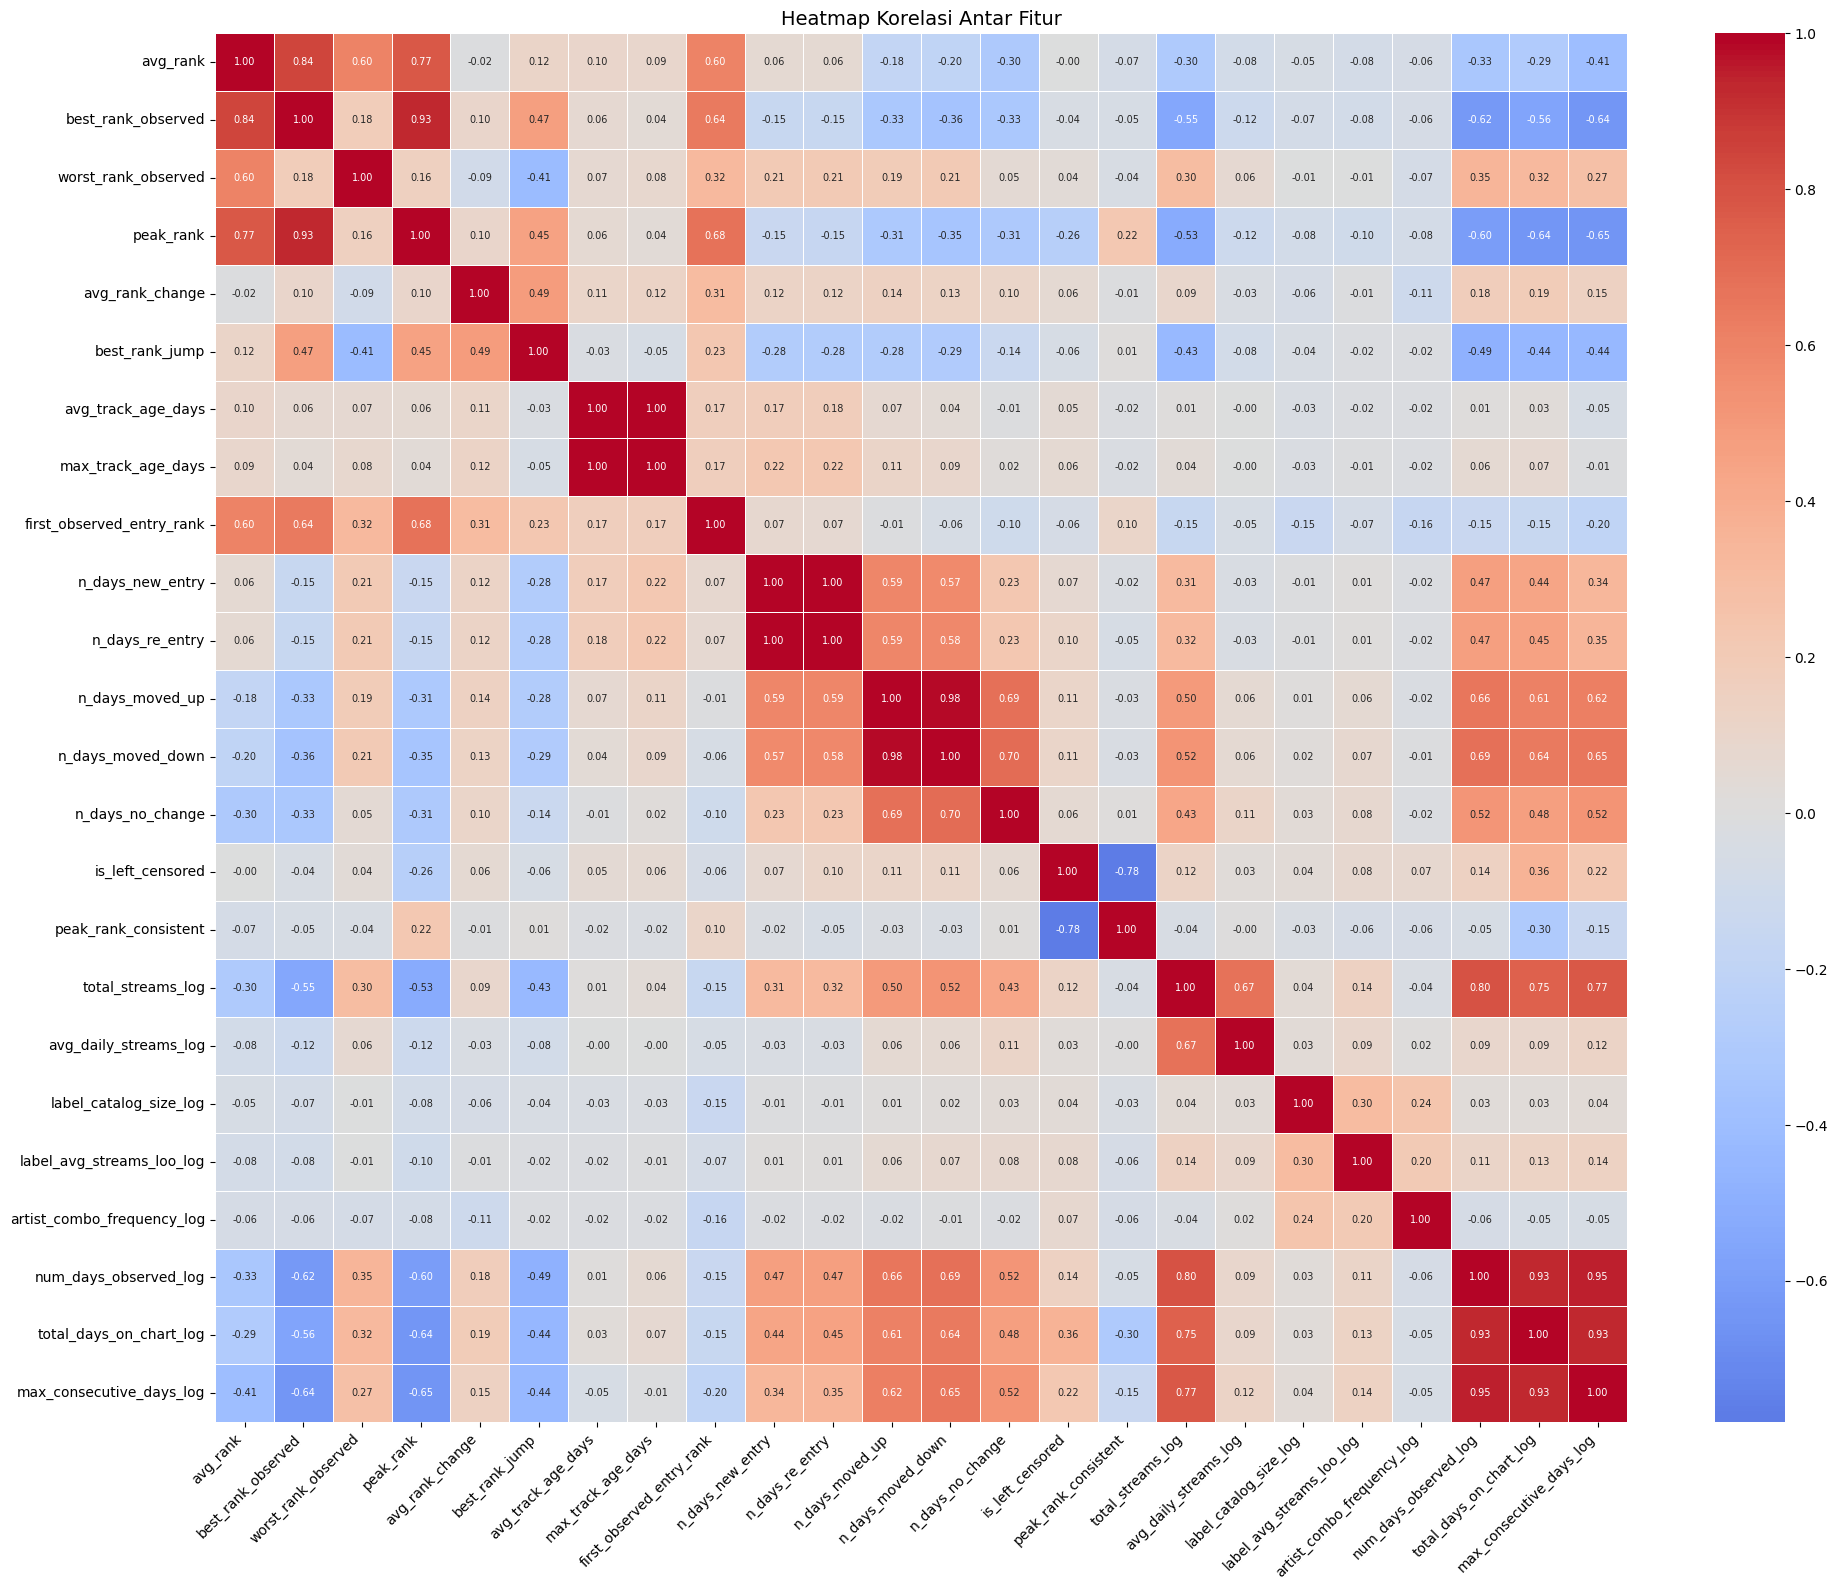

In [ ]:
# ============================================
# PLOT 1 — Heatmap Korelasi
# ============================================
plt.figure(figsize=(20, 16))
sns.heatmap(
    df_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot_kws={"size": 7}
)
plt.title("Heatmap Korelasi Antar Fitur", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# **Load**

In [ ]:
import pyarrow as pa
import pyarrow.parquet as pq

# Export df_final (Pandas) ke single parquet file
output_path = "/content/drive/MyDrive/spotify/csd_model.parquet"

pq.write_table(
    pa.Table.from_pandas(df_final),
    output_path
)

print(f"✅ File berhasil disimpan: {output_path}")
print(f"   Shape : {df_final.shape}")
print(f"   Size  : {df_final.memory_usage(deep=True).sum() / 1e6:.2f} MB")

✅ File berhasil disimpan: /content/drive/MyDrive/spotify/csd_model.parquet
   Shape : (663817, 27)
   Size  : 289.65 MB
